# Shift Profitability Analysis

Analysis of server shift data (hours, wage, cash/card tips) collected from the
[Server Pay Tracker](../) app. This notebook goes beyond the Java app's simple
averages to test whether shift-type/day differences are statistically meaningful,
and fits a basic model of what predicts tip income.

**Data source:** `shiftDatabase.txt` (or a `shifts` export from the app's Postgres DB),
columns: `date, type, hours, wage, cash_tips, card_tips`, no header row.


## 1. Connect to the database and load data

Pulls directly from the same Supabase Postgres `shifts` table your Spring Boot
app writes to, instead of a flat-file export. Uses the same
`SUPABASE_DB_PASSWORD` environment variable your `DatabaseManager` already
reads — nothing new to configure on that front.


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
from sqlalchemy import create_engine

# --- Fill these in from the same values your Java DatabaseManager uses ---
DB_USER = "postgres.sgjfjjgstkoufgdfmcpm"   # Supabase session pooler user, e.g. postgres.abcxyz123
DB_HOST = "aws-0-us-west-2.pooler.supabase.com"  # session pooler host from your Supabase dashboard
DB_PORT = "5432"
DB_NAME = "postgres"
DB_PASSWORD = os.environ["SUPABASE_DB_PASSWORD"]  # same env var your Java app reads

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

# Adjust table/column names if yours differ (check your ShiftDAO / schema.sql)
query = """
    SELECT date, type, hours, wage, cash_tips, card_tips
    FROM shifts
    ORDER BY date
"""
df = pd.read_sql(query, engine)

df["date"] = pd.to_datetime(df["date"])
df["gross_pay"] = df["hours"] * df["wage"] + df["cash_tips"] + df["card_tips"]
df["total_tips"] = df["cash_tips"] + df["card_tips"]
df["tips_per_hour"] = df["total_tips"] / df["hours"]
df["day_of_week"] = df["date"].dt.day_name()

df.sort_values("date").head()


,date,type,hours,wage,cash_tips,card_tips,gross_pay,total_tips,tips_per_hour,day_of_week
0,2026-07-03,NIGHT,6.0,12.0,90.0,60.0,222.0,150.0,25.000000,Friday
1,2026-07-05,EVENING,7.0,15.5,55.0,60.0,223.5,115.0,16.428571,Sunday
2,2026-07-06,MORNING,6.0,11.0,15.0,10.0,91.0,25.0,4.166667,Monday
3,2026-07-10,NIGHT,6.0,12.0,85.0,70.0,227.0,155.0,25.833333,Friday
4,2026-07-12,EVENING,7.0,15.5,60.0,55.0,223.5,115.0,16.428571,Sunday


## 2. Reproduce the app's profitability ranking (in pandas)

Same idea as `calculator.shiftProfitability()` — average gross pay and tips per
(day-of-week, shift-type) combo — but as a one-line groupby instead of a
hand-rolled `HashMap<String, ShiftStats>`.


In [3]:
summary = (
    df.groupby(["day_of_week", "type"])
      .agg(avg_gross=("gross_pay", "mean"),
           avg_tips=("total_tips", "mean"),
           avg_tips_per_hour=("tips_per_hour", "mean"),
           n_shifts=("gross_pay", "size"))
      .sort_values("avg_gross", ascending=False)
)
summary


avg_gross    avg_tips  avg_tips_per_hour  n_shifts
day_of_week type                                                          
Friday      NIGHT      234.428571  160.714286          26.172161         7
Sunday      EVENING    228.791667  119.000000          16.809524         6
Saturday    NIGHT      221.000000  149.000000          24.833333         2
Sunday      AFTERNOON  130.000000   52.500000          10.500000         2
            MORNING    112.500000   35.000000           7.000000         2
Monday      AFTERNOON   97.666667   42.666667           8.533333         3
            MORNING     89.333333   23.333333           3.888889         6

## 3. Is the morning/evening difference statistically significant?

The app currently just ranks averages, which can be misleading with small sample
sizes. Here we run a two-sample t-test on tips-per-hour between MORNING and
EVENING shifts to check whether the gap is likely real or just noise.


In [4]:
morning = df.loc[df["type"] == "MORNING", "tips_per_hour"]
evening = df.loc[df["type"] == "EVENING", "tips_per_hour"]

t_stat, p_value = stats.ttest_ind(evening, morning, equal_var=False)

print(f"Evening mean tips/hr: {evening.mean():.2f}  (n={len(evening)})")
print(f"Morning mean tips/hr: {morning.mean():.2f}  (n={len(morning)})")
print(f"t-statistic: {t_stat:.3f}, p-value: {p_value:.4f}")

if p_value < 0.05:
    print("-> Statistically significant difference at alpha = 0.05")
else:
    print("-> Not statistically significant at alpha = 0.05 (could be sample size)")


Evening mean tips/hr: 16.81  (n=6)
Morning mean tips/hr: 4.67  (n=8)
t-statistic: 20.530, p-value: 0.0000
-> Statistically significant difference at alpha = 0.05


## 4. What predicts tips per hour?

A simple OLS regression of `tips_per_hour` on day-of-week and shift type, as a
first pass at a predictive model (swap in a GLM / regularized model once there's
more data, e.g. weeks of history, weather, day-of-month/payday effects, etc.).


In [5]:
model = smf.ols("tips_per_hour ~ C(day_of_week) + C(type)", data=df).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:          tips_per_hour   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                     463.7
Date:                Tue, 22 Sep 2026   Prob (F-statistic):           1.61e-21
Time:                        11:22:23   Log-Likelihood:                -35.104
No. Observations:                  28   AIC:                             82.21
Df Residuals:                      22   BIC:                             90.20
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

C:\Users\15748\AppData\Local\Temp\ipykernel_34148\3580585945.py:1: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model = smf.ols("tips_per_hour ~ C(day_of_week) + C(type)", data=df).fit()


## 5. Visualizations

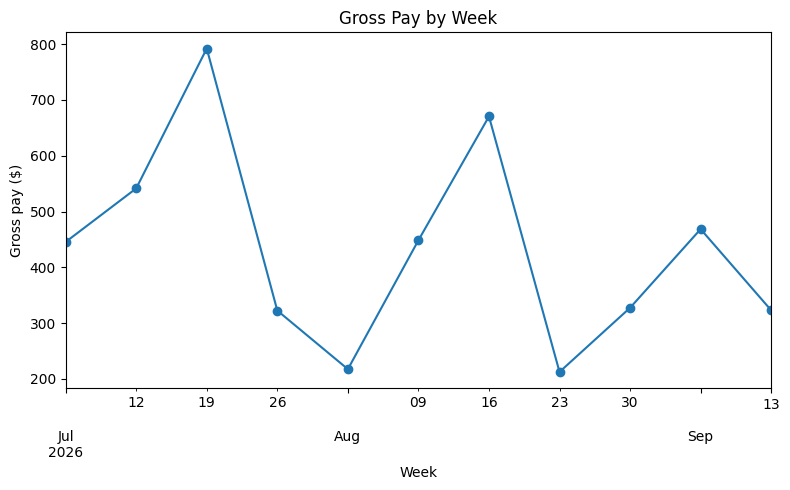

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
weekly = df.set_index("date")["gross_pay"].resample("W").sum()
weekly.plot(ax=ax, marker="o")
ax.set_title("Gross Pay by Week")
ax.set_ylabel("Gross pay ($)")
ax.set_xlabel("Week")
plt.tight_layout()
plt.savefig("gross_pay_by_week.png", dpi=150)
plt.show()


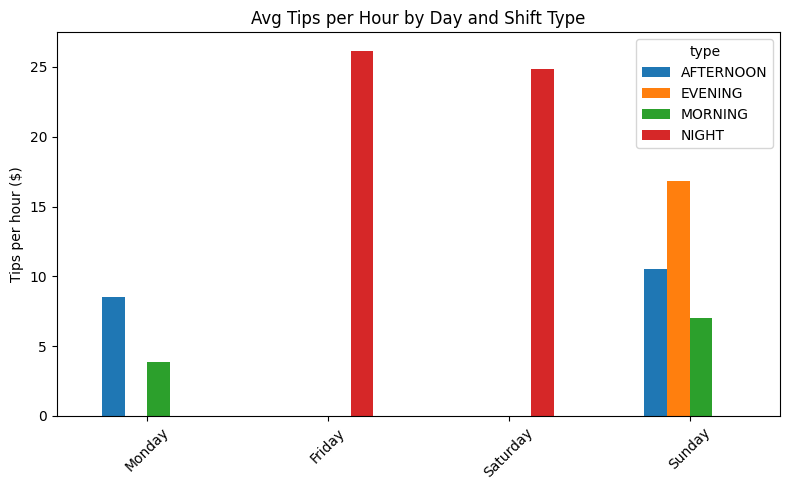

In [7]:
pivot = df.pivot_table(index="day_of_week", columns="type",
                       values="tips_per_hour", aggfunc="mean")
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
pivot = pivot.reindex([d for d in day_order if d in pivot.index])

fig, ax = plt.subplots(figsize=(8, 5))
pivot.plot(kind="bar", ax=ax)
ax.set_title("Avg Tips per Hour by Day and Shift Type")
ax.set_ylabel("Tips per hour ($)")
ax.set_xlabel("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("tips_per_hour_by_day_type.png", dpi=150)
plt.show()


## 6. Findings (fill in after running on real data)

- Highest-earning day/shift combo:
- Statistically significant morning vs. evening gap? (see Section 3 p-value)
- Strongest predictor(s) of tips per hour from the regression:
- Caveats: sample size, no weather/event data yet, single venue
